# Notebook 2 — Well A-08 Hodge Monitoring

Sliding-window Hodge + persistence monitoring on two real recordings from well **A-08**,
analysing both sensor channels:

| Channel | Physical meaning |
|---|---|
| **BHP** | Bottom-hole pressure — downhole sensor |
| **Flowline Pressure** | Topside / wellhead outlet pressure |

Both recordings: 34 560 samples, 10 s resolution (4 days).

## Pipeline (Persistent Homology + Hodge Decomposition)

```
Signal (1D)
  └─ gtda SlidingWindow          → windows  (n_windows, W)
       └─ gtda TakensEmbedding   → point clouds  (n_windows, n_pts, d)
            ├─ gtda VRP + PersistenceEntropy / Amplitude / BettiCurve
            │    → persistence features per window
            └─ (our) Hodge decomposition + L₁ spectrum
                 → η_harm, spectral gap per window
```

GiottoTDA handles the windowing and persistence track entirely;
the Hodge track runs on the same embeddings.

## 1. Imports and configuration

In [55]:
import sys, pathlib, pickle, warnings
sys.path.insert(0, str(pathlib.Path('..').resolve()))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from joblib import Parallel, delayed

# ── GiottoTDA ─────────────────────────────────────────────────────────────
from gtda.time_series import SlidingWindow, TakensEmbedding, SingleTakensEmbedding
from gtda.homology    import VietorisRipsPersistence
from gtda.diagrams    import PersistenceEntropy, Amplitude, BettiCurve

# ── Hodge modules (our code) ───────────────────────────────────────────────
from hodge.boundary_matrices import get_rips_simplices, build_boundary_matrices, angle_to_1cochain
from hodge.decomposition     import hodge_decomposition
from hodge.spectrum          import compute_l1_spectrum
from utils.epsilon_selection import epsilon_from_diagram

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR  = pathlib.Path('/Users/simo/Repos/TDA/Slugging/Data/Slugging')
FILE_1    = DATA_DIR / 'slug_1_A-08 (1).csv'
FILE_2    = DATA_DIR / 'slug_2_A-08.csv'
CACHE_DIR = pathlib.Path('../data')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Monitoring parameters ──────────────────────────────────────────────────
FS        = 0.1      # Hz  (10 s resolution)
WINDOW    = 300     # samples  (3 000 s = 50 min)
STRIDE    = 60      # samples  (600 s = 10 min)
# DIM and TAU are determined automatically in §3 (see optimal-embedding cell).
N_EIGS    = 10       # L₁ eigenvalues per window

# ── Hodge parameters ───────────────────────────────────────────────────────
HODGE_N_JOBS = 2     # kept for hodge_features() helper; main loop is sequential
HODGE_BATCH  = 25    # kept for old-checkpoint migration
EPS_MIN      = 0.1   # floor on the Vietoris–Rips filtration parameter

print(f"Window {WINDOW} samples = {WINDOW/FS/3600:.1f} h  |  "
      f"Stride {STRIDE} samples = {STRIDE/FS/60:.0f} min  |  "
      f"EPS_MIN = {EPS_MIN}")


Window 300 samples = 0.8 h  |  Stride 60 samples = 10 min  |  EPS_MIN = 0.1


In [56]:
# Publication figure style (matches sbi_mcmc_heat_exchanger nb 07)
plt.rcParams.update({
    "axes.labelsize":  14,
    "axes.titlesize":  14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.constrained_layout.use": True,
})


## 2. Load data

In [57]:
def load_well_csv(path):
    df = pd.read_csv(path, parse_dates=[0])
    df = df.rename(columns={df.columns[0]: 'timestamp'})
    df['time_s'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
    return df

df1 = load_well_csv(FILE_1)
df2 = load_well_csv(FILE_2)

for name, df in [("Recording 1 (Apr 2020)", df1), ("Recording 2 (Jul 2020)", df2)]:
    print(f"{name}: {len(df)} samples  |  "
          f"BHP [{df['BHP'].min():.1f}–{df['BHP'].max():.1f}] bar  |  "
          f"FLP [{df['Flowline Pressure'].min():.2f}–{df['Flowline Pressure'].max():.2f}] bar")

Recording 1 (Apr 2020): 34560 samples  |  BHP [160.9–167.4] bar  |  FLP [8.27–10.33] bar
Recording 2 (Jul 2020): 34560 samples  |  BHP [146.1–169.4] bar  |  FLP [7.20–9.98] bar


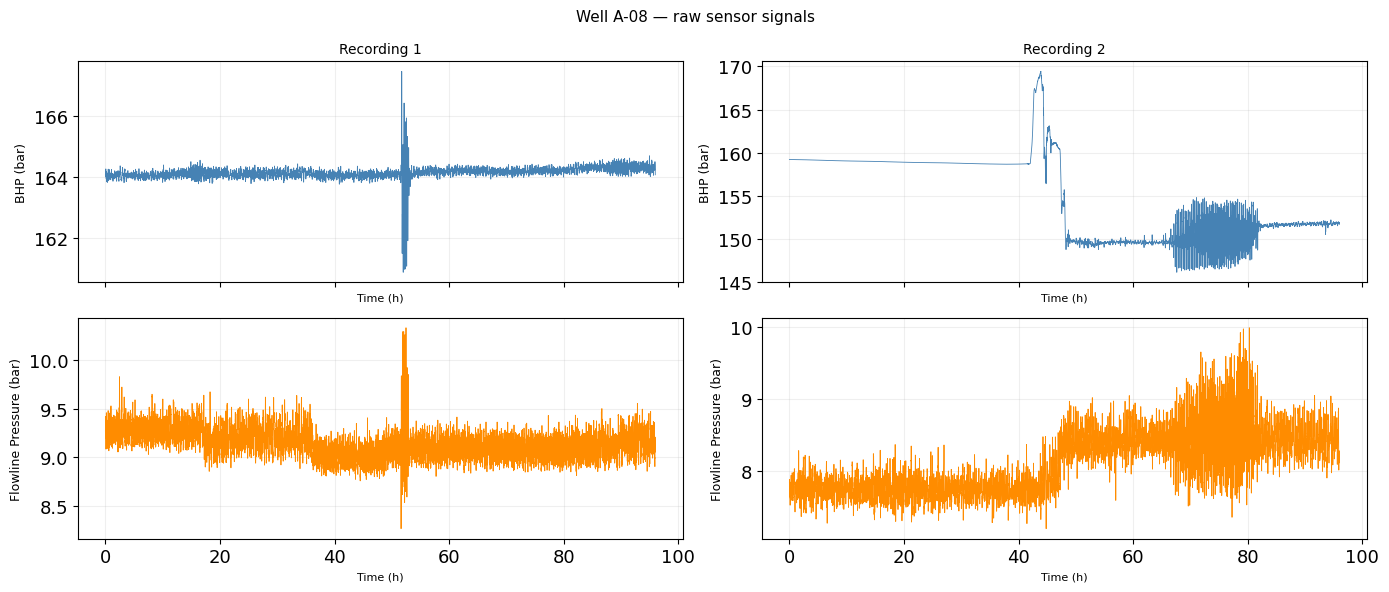

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex='col')
for col_i, (name, df) in enumerate([("Recording 1", df1), ("Recording 2", df2)]):
    t_h = df['time_s'] / 3600
    axes[0, col_i].plot(t_h, df['BHP'],              lw=0.6, color='steelblue')
    axes[1, col_i].plot(t_h, df['Flowline Pressure'], lw=0.6, color='darkorange')
    axes[0, col_i].set_title(name, fontsize=10)
    for ax, ylabel in zip(axes[:, col_i], ['BHP (bar)', 'Flowline Pressure (bar)']):
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xlabel('Time (h)', fontsize=8)
        ax.grid(alpha=0.2)
plt.suptitle('Well A-08 — raw sensor signals', fontsize=11)
plt.tight_layout(); plt.show()

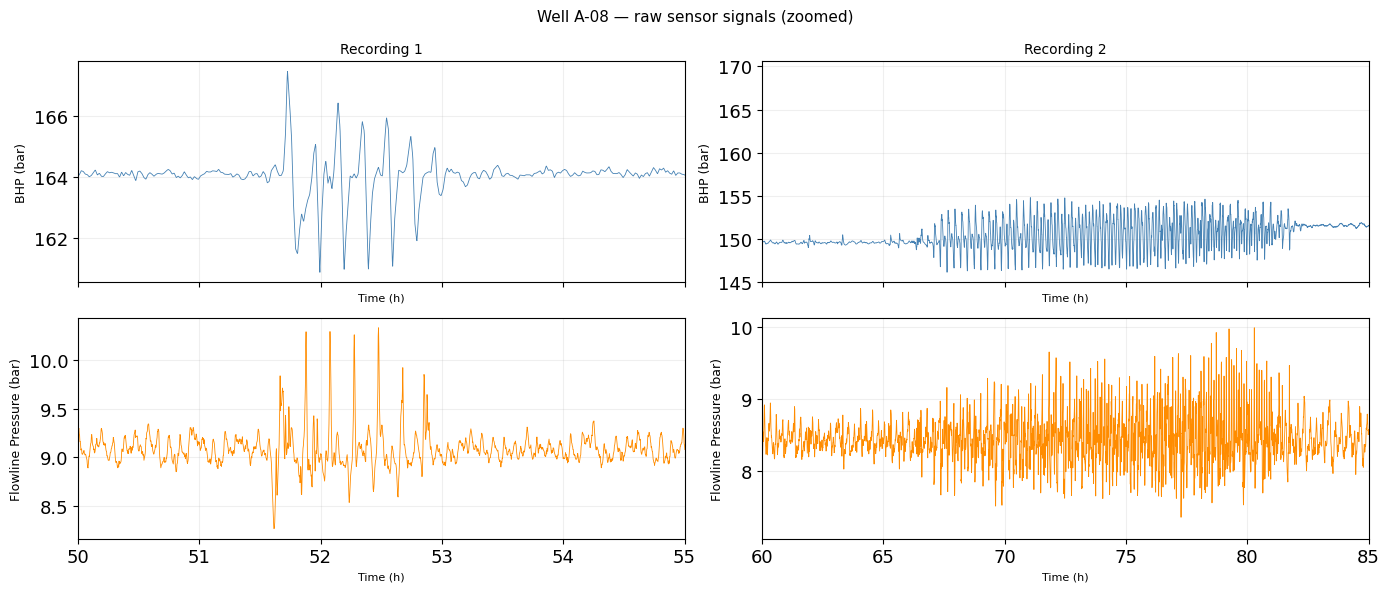

In [59]:
# same plot but zoomed in on the interval [40 h, 460 h] for the left panels and [60 h, 90 h] to show the slugging events more clearly.

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex='col')
for col_i, (name, df) in enumerate([("Recording 1", df1), ("Recording 2", df2)]):
    t_h = df['time_s'] / 3600
    axes[0, col_i].plot(t_h, df['BHP'],              lw=0.6, color='steelblue')
    axes[1, col_i].plot(t_h, df['Flowline Pressure'], lw=0.6, color='darkorange')
    axes[0, col_i].set_title(name, fontsize=10)
    for ax, ylabel in zip(axes[:, col_i], ['BHP (bar)', 'Flowline Pressure (bar)']):
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xlabel('Time (h)', fontsize=8)
        ax.grid(alpha=0.2)
axes[0, 0].set_xlim(50, 55)
axes[0, 1].set_xlim(60, 85)
plt.suptitle('Well A-08 — raw sensor signals (zoomed)', fontsize=11)
plt.tight_layout(); plt.show()  

## 3. GiottoTDA persistence pipeline

We build a vectorised GiottoTDA pipeline that processes all windows at once:

1. **`SlidingWindow`** — splits the signal into overlapping windows of shape `(n_windows, W)`
2. **`TakensEmbedding`** — embeds each window into a point cloud `(n_windows, n_pts, d)`
3. **`VietorisRipsPersistence`** — computes persistence diagrams for all windows
4. **Feature extractors** — `PersistenceEntropy`, `Amplitude` (max persistence), `BettiCurve`

This is entirely vectorised by GiottoTDA; no Python-level loops needed for the
persistence track.

In [60]:
# ── Optimal Takens embedding parameters (DIM, TAU) ────────────────────────
# Search on BHP only, on a single WINDOW-sample window centred on a
# representative slugging interval per recording:
#   Recording 1 → hour 53
#   Recording 2 → hour 72
# GiottoTDA's SingleTakensEmbedding(parameters_type='search') selects τ via
# the first minimum of mutual information and d via false-nearest-neighbours
# (Kennel et al., 1992). We then take the MAX dimension and MAX time_delay
# across the two recordings and use the same (DIM, TAU) for everything.

_EMBED_PROBE_HOURS = {'rec1': 53.0, 'rec2': 72.0}
_TAU_MAX = 30
_DIM_MAX = 10

def _bhp_window(df, hour_centre, window=WINDOW, fs=FS):
    centre_idx = int(round(hour_centre * 3600 * fs))
    half       = window // 2
    lo, hi     = max(0, centre_idx - half), centre_idx + (window - half)
    return df['BHP'].values[lo:hi].astype(float)

_opt = {}
for rec, df in [('rec1', df1), ('rec2', df2)]:
    sig = _bhp_window(df, _EMBED_PROBE_HOURS[rec])
    ste = SingleTakensEmbedding(parameters_type='search',
                                time_delay=_TAU_MAX, dimension=_DIM_MAX,
                                n_jobs=-1)
    _   = ste.fit_transform(sig)
    _opt[rec] = (int(ste.dimension_), int(ste.time_delay_))
    print(f"  {rec}  (hour {_EMBED_PROBE_HOURS[rec]:.0f})  →  "
          f"dimension = {ste.dimension_}, time_delay = {ste.time_delay_}")

DIM = max(d for d, _ in _opt.values())
TAU = max(t for _, t in _opt.values())
print(f"\nSelected for the rest of the notebook (max across recordings):  "
      f"DIM = {DIM}, TAU = {TAU}")


  rec1  (hour 53)  →  dimension = 4, time_delay = 21
  rec2  (hour 72)  →  dimension = 6, time_delay = 14

Selected for the rest of the notebook (max across recordings):  DIM = 6, TAU = 21


In [61]:
# Instantiate GiottoTDA transformers
sw  = SlidingWindow(size=WINDOW, stride=STRIDE)
te  = TakensEmbedding(time_delay=TAU, dimension=DIM)
vrp = VietorisRipsPersistence(homology_dimensions=[0, 1, 2], n_jobs=-1)
PE  = PersistenceEntropy(nan_fill_value=0.0)
BC  = BettiCurve(n_bins=20)

def max_persistence_per_dim(diagrams, dims=(0, 1, 2)):
    """For each diagram and each homology dim, return the longest bar length
    (max d - b). Returns an array of shape (n_windows, len(dims))."""
    out = np.zeros((len(diagrams), len(dims)), dtype=float)
    for i, diag in enumerate(diagrams):
        life = diag[:, 1] - diag[:, 0]
        for j, d in enumerate(dims):
            mask = (diag[:, 2] == d) & (life > 0)
            out[i, j] = life[mask].max() if mask.any() else 0.0
    return out

def persistence_features(signal):
    """Run the full GiottoTDA persistence track on a 1-D signal.
    Returns a DataFrame with one row per window."""
    windows_raw = sw.fit_transform(signal.reshape(-1, 1))   # (n_windows, W, 1)
    windows     = windows_raw.squeeze(-1) if windows_raw.ndim == 3 else windows_raw
    embeddings  = te.fit_transform(windows)                  # (n_windows, n_pts, d)
    diagrams    = vrp.fit_transform(embeddings)              # (n_windows, n_feats, 3)

    entropy   = PE.fit_transform(diagrams)            # (n_windows, 3)
    p_inf     = max_persistence_per_dim(diagrams)     # (n_windows, 3) — longest bar
    betti     = BC.fit_transform(diagrams)            # (n_windows, 3, n_bins)

    df = pd.DataFrame({
        'entropy_h0':  entropy[:, 0],
        'entropy_h1':  entropy[:, 1],
        'entropy_h2':  entropy[:, 2],
        'p_inf_h0':    p_inf[:, 0],
        'p_inf_h1':    p_inf[:, 1],
        'p_inf_h2':    p_inf[:, 2],
        'mean_betti0': betti[:, 0, :].mean(axis=1),
        'mean_betti1': betti[:, 1, :].mean(axis=1),
        'mean_betti2': betti[:, 2, :].mean(axis=1),
    })
    df.attrs['embeddings'] = embeddings
    df.attrs['diagrams']   = diagrams
    return df

print("Persistence pipeline ready (H0, H1, H2). p_inf_* = longest bar per dim.")


Persistence pipeline ready (H0, H1, H2). p_inf_* = longest bar per dim.


## 4. Hodge track

For each window we:
1. Select ε from the persistence diagram (most-persistent H₁ midpoint)
2. Build the Vietoris–Rips complex at that ε
3. Compute the angle 1-cochain and run Hodge decomposition
4. Compute the L₁ spectrum

This runs per-window in parallel via joblib.

In [62]:
def hodge_features_one(embedding, diagram, eps=None):
    """Hodge decomposition + L₁ spectrum for one window.

    Pass a pre-computed eps to avoid recomputing it (allows the caller
    to print it before the expensive complex construction starts).
    """
    zero = dict(eta_harm=0., eta_grad=0., eta_curl=0.,
                harm_curl_ratio=0., beta1_hodge=0,
                lambda1=0., spectral_gap=0.)
    if eps is None:
        eps = epsilon_from_diagram(diagram, strategy='second_persistent_half')
    if eps is None:
        return zero
    sc = get_rips_simplices(embedding, eps, max_dim=2)
    if len(sc.edges) < 3 or len(sc.triangles) == 0:
        return zero
    B1, B2 = build_boundary_matrices(sc)
    from sklearn.decomposition import PCA
    pca2 = PCA(n_components=2).fit_transform(embedding)
    f1   = angle_to_1cochain(pca2, sc, dims=(0, 1))
    dec  = hodge_decomposition(f1, B1, B2)
    spec = compute_l1_spectrum(B1, B2, n_eigs=min(N_EIGS, len(sc.edges) - 2))
    return dict(eta_harm=dec.eta_harm, eta_grad=dec.eta_grad,
                eta_curl=dec.eta_curl,
                harm_curl_ratio=dec.harm_curl_ratio,
                beta1_hodge=spec.beta1_hodge,
                lambda1=spec.lambda1,
                spectral_gap=spec.spectral_gap)


def hodge_features(embeddings, diagrams, n_jobs=-1):
    """Hodge features for all windows, parallelised via joblib."""
    results = Parallel(n_jobs=n_jobs, verbose=2)(
        delayed(hodge_features_one)(embeddings[i], diagrams[i])
        for i in range(len(embeddings))
    )
    return pd.DataFrame(results)

print("Hodge feature extractor ready.")

Hodge feature extractor ready.


## 5. Two-phase pipeline

The Hodge decomposition is expensive (Rips complex construction + eigensolve per window).
We run it in two phases to avoid paying that cost on every window:

**Phase 1 — Persistence screening** (this section)  
Run the full GiottoTDA persistence track on every window (vectorised, cheap).
Inspect the max H₁ persistence `p_inf_h1` as a proxy for topological activity.

**Phase 2 — Hodge on selected windows** (§5c)  
Apply Hodge only to windows where `p_inf_h1` exceeds a user-chosen threshold.

In [63]:
### 5a. Phase 1 — Persistence screening

def run_persistence(df, signal_col, cache_tag):
    """Run persistence pipeline only. Embeddings and diagrams cached alongside features.

    If the cache exists but was built without H2 (missing p_inf_h2 column),
    it is automatically invalidated and recomputed.
    """
    cache = CACHE_DIR / f"nb02_pers_{cache_tag}.pkl"
    if cache.exists():
        with open(cache, "rb") as fh:
            payload = pickle.load(fh)
        if 'p_inf_h2' in payload['pers'].columns:
            print(f"  Loading persistence {cache_tag} …")
            return payload
        print(f"  Cache {cache_tag} outdated (no H2) — recomputing …")
        cache.unlink()

    print(f"  Computing persistence {cache_tag} …")
    signal = df[signal_col].values.astype(float)
    times  = df['time_s'].values

    pers_df    = persistence_features(signal)
    embeddings = pers_df.attrs['embeddings']   # (n_windows, n_pts, d)
    diagrams   = pers_df.attrs['diagrams']     # (n_windows, n_feats, 3)

    n_win     = len(pers_df)
    t_centres = np.array([
        times[min(i * STRIDE + WINDOW // 2, len(times) - 1)]
        for i in range(n_win)
    ])
    pers_df.insert(0, 'time', t_centres)

    payload = {'pers': pers_df, 'embeddings': embeddings, 'diagrams': diagrams}
    with open(cache, "wb") as fh:
        pickle.dump(payload, fh)
    print(f"    → {n_win} windows cached → {cache.name}")
    return payload

print("Pipelines ready. Starting phase 1: persistence screening.")
print()

print(f"number of windows = {(len(df1) - WINDOW) // STRIDE + 1} per recording")
print(f"length of windows in seconds = {WINDOW / FS:.0f} s")
print(f"length of windows in hours = {WINDOW / FS / 3600:.1f} h")
print(f"stride = {STRIDE} samples = {STRIDE / FS / 60:.0f} min")
print()

print("Recording 1 — Persistence screening:")
p1_bhp = run_persistence(df1, 'BHP',               'rec1_bhp')
p1_flp = run_persistence(df1, 'Flowline Pressure',  'rec1_flp')

print("\nRecording 2 — Persistence screening:")
p2_bhp = run_persistence(df2, 'BHP',               'rec2_bhp')
p2_flp = run_persistence(df2, 'Flowline Pressure',  'rec2_flp')

Pipelines ready. Starting phase 1: persistence screening.

number of windows = 572 per recording
length of windows in seconds = 3000 s
length of windows in hours = 0.8 h
stride = 60 samples = 10 min

Recording 1 — Persistence screening:
  Loading persistence rec1_bhp …
  Loading persistence rec1_flp …

Recording 2 — Persistence screening:
  Loading persistence rec2_bhp …
  Loading persistence rec2_flp …


### 5b. Inspect max H₁ and H₂ persistence — visualise window activity

Plot `p_inf_h1` and `p_inf_h2` (highest H₁ and H₂ persistence in each window) for all
four signal combinations.  Hodge decomposition will be run on the time intervals of interest:
**Recording 1 → [40, 60] h** · **Recording 2 → [60, 90] h**

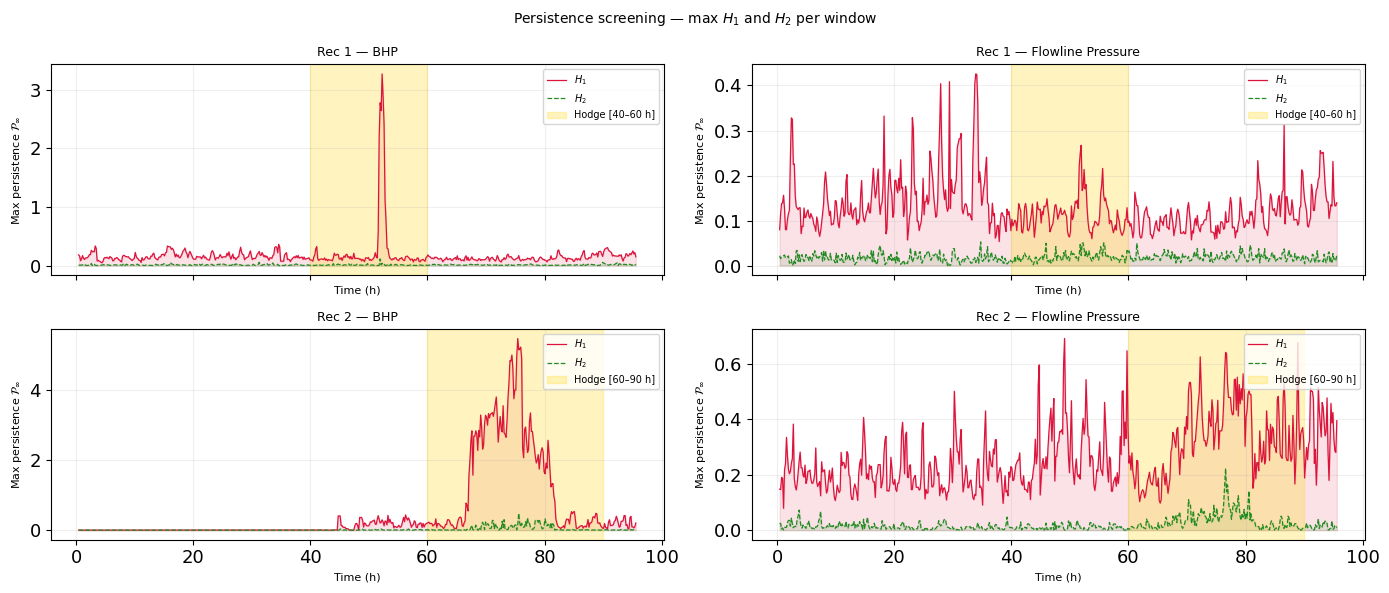

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex='col')
panels = [
    (p1_bhp, 'Rec 1 — BHP',               (40, 60), 0, 0),
    (p1_flp, 'Rec 1 — Flowline Pressure',  (40, 60), 0, 1),
    (p2_bhp, 'Rec 2 — BHP',               (60, 90), 1, 0),
    (p2_flp, 'Rec 2 — Flowline Pressure',  (60, 90), 1, 1),
]
for payload, title, (t0, t1), row, col in panels:
    ax  = axes[row, col]
    t_h = payload['pers']['time'].values / 3600
    p1  = payload['pers']['p_inf_h1'].values
    p2  = payload['pers']['p_inf_h2'].values

    ax.plot(t_h, p1, lw=0.9, color='crimson',     label='$H_1$')
    ax.fill_between(t_h, p1, alpha=0.12, color='crimson')
    ax.plot(t_h, p2, lw=0.9, color='forestgreen', label='$H_2$', ls='--')
    ax.fill_between(t_h, p2, alpha=0.10, color='forestgreen')

    ax.axvspan(t0, t1, color='gold', alpha=0.25, label=f'Hodge [{t0}–{t1} h]')
    ax.set_title(title, fontsize=9)
    ax.set_ylabel(r'Max persistence $\mathcal{P}_\infty$', fontsize=8)
    ax.set_xlabel('Time (h)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.2)

plt.suptitle('Persistence screening — max $H_1$ and $H_2$ per window', fontsize=10)
plt.tight_layout()
plt.show()

In [65]:
# ── Time-range selection for Hodge decomposition ──────────────────────────
REC1_HODGE_RANGE = (40, 60)   # hours
REC2_HODGE_RANGE = (60, 90)   # hours

def select_windows_by_time(payload, t_start_h, t_end_h):
    """Boolean mask: True for windows whose centre falls in [t_start_h, t_end_h]."""
    t_h   = payload['pers']['time'].values / 3600
    mask  = (t_h >= t_start_h) & (t_h <= t_end_h)
    n_sel = mask.sum()
    print(f"  {n_sel:4d} / {len(mask)} windows selected  "
          f"({t_start_h}–{t_end_h} h)")
    return mask

m1_bhp = select_windows_by_time(p1_bhp, *REC1_HODGE_RANGE)
m1_flp = select_windows_by_time(p1_flp, *REC1_HODGE_RANGE)
m2_bhp = select_windows_by_time(p2_bhp, *REC2_HODGE_RANGE)
m2_flp = select_windows_by_time(p2_flp, *REC2_HODGE_RANGE)

   120 / 572 windows selected  (40–60 h)
   120 / 572 windows selected  (40–60 h)
   180 / 572 windows selected  (60–90 h)
   180 / 572 windows selected  (60–90 h)


### Save point clouds & persistence features over selected ranges

 For every (recording, channel) combination we restrict to the windows
 selected by REC*_HODGE_RANGE and save to ../outputs/:
   - point clouds (Takens embeddings) as .npz
   - PE / AMP / BC arrays as .npz  +  per-window summary CSV
 Finally we visualise (via giotto-tda) the point cloud with the
 highest H1 persistence within the selected ranges — restricted to FLP.

In [66]:
from gtda.plotting import plot_point_cloud

OUT_DIR = pathlib.Path('../outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

_SELECTED = [
    ('rec1_bhp', p1_bhp, m1_bhp),
    ('rec1_flp', p1_flp, m1_flp),
    ('rec2_bhp', p2_bhp, m2_bhp),
    ('rec2_flp', p2_flp, m2_flp),
]

# Track the top-H1 window per recording on the BHP channel for point-cloud
# visualisation.
_BHP_TAGS = ('rec1_bhp', 'rec2_bhp')
_top_bhp = {}   # tag → dict(val, local_i, global_i, embedding, diagram, pers_row)

for _tag, _pl, _mask in _SELECTED:
    _idx_sel   = np.where(_mask)[0]
    _emb_sel   = _pl['embeddings'][_idx_sel]   # (n_sel, n_pts, d)
    _diag_sel  = _pl['diagrams'][_idx_sel]     # (n_sel, n_feats, 3)
    _pers_sel  = _pl['pers'].iloc[_idx_sel].reset_index(drop=True)

    # PE / BC on the selected diagrams; p_inf_* already in _pers_sel (longest bar)
    _pe_sel  = PE.fit_transform(_diag_sel)     # (n_sel, 3)
    _bc_sel  = BC.fit_transform(_diag_sel)     # (n_sel, 3, n_bins)
    _pinf_sel = _pers_sel[['p_inf_h0', 'p_inf_h1', 'p_inf_h2']].values

    # ── save point clouds + diagrams + features ───────────────────────────
    _pc_path = OUT_DIR / f"nb02_pointclouds_{_tag}.npz"
    np.savez_compressed(
        _pc_path,
        embeddings=_emb_sel,
        diagrams=_diag_sel,
        time=_pers_sel['time'].values,
        window_index=_idx_sel.astype(np.int64),
    )

    _feat_path = OUT_DIR / f"nb02_persfeatures_{_tag}.npz"
    np.savez_compressed(
        _feat_path,
        entropy=_pe_sel,          # columns: H0, H1, H2
        max_persistence=_pinf_sel, # columns: H0, H1, H2 (longest bar)
        betti=_bc_sel,            # (n_sel, 3, n_bins)
        time=_pers_sel['time'].values,
        window_index=_idx_sel.astype(np.int64),
    )

    _summary = pd.DataFrame({
        'window_index': _idx_sel,
        'time_s':       _pers_sel['time'].values,
        'entropy_h0':   _pe_sel[:, 0],
        'entropy_h1':   _pe_sel[:, 1],
        'entropy_h2':   _pe_sel[:, 2],
        'p_inf_h0':     _pinf_sel[:, 0],
        'p_inf_h1':     _pinf_sel[:, 1],
        'p_inf_h2':     _pinf_sel[:, 2],
        'mean_betti0':  _bc_sel[:, 0, :].mean(axis=1),
        'mean_betti1':  _bc_sel[:, 1, :].mean(axis=1),
        'mean_betti2':  _bc_sel[:, 2, :].mean(axis=1),
    })
    _summary.to_csv(OUT_DIR / f"nb02_persfeatures_{_tag}.csv", index=False)

    print(f"  [{_tag}]  {len(_idx_sel):3d} windows  →  "
          f"{_pc_path.name}, {_feat_path.name}")

    # Per-recording top H1 window — BHP channel only
    if _tag not in _BHP_TAGS:
        continue
    _local_i = int(np.argmax(_pinf_sel[:, 1]))
    _top_bhp[_tag] = dict(
        val=float(_pinf_sel[_local_i, 1]),
        local_i=_local_i,
        global_i=int(_idx_sel[_local_i]),
        embedding=_emb_sel[_local_i],
        diagram=_diag_sel[_local_i],
        pers_row=_summary.iloc[_local_i],
    )

print()
for _tag, _top in _top_bhp.items():
    print(f"Top H1 ({_tag}, BHP): window {_top['global_i']}  "
          f"P_inf(H1) = {_top['val']:.4f}")

# ── Giotto-TDA point-cloud visualisation (auto-PCA to 3D) ─────────────────
# One figure per recording, BHP channel.
for _tag, _top in _top_bhp.items():
    _fig_pc = plot_point_cloud(
        _top['embedding'],
        dimension=3,
        plotly_params={
            'layout': {
                'title': (
                    f"Highest H1 window — {_tag}  "
                    f"(global idx {_top['global_i']}, "
                    f"P_inf(H1) = {_top['val']:.4f})"
                ),
                'width':  700,
                'height': 600,
            }
        },
    )
    _fig_pc.show()


  [rec1_bhp]  120 windows  →  nb02_pointclouds_rec1_bhp.npz, nb02_persfeatures_rec1_bhp.npz
  [rec1_flp]  120 windows  →  nb02_pointclouds_rec1_flp.npz, nb02_persfeatures_rec1_flp.npz
  [rec2_bhp]  180 windows  →  nb02_pointclouds_rec2_bhp.npz, nb02_persfeatures_rec2_bhp.npz
  [rec2_flp]  180 windows  →  nb02_pointclouds_rec2_flp.npz, nb02_persfeatures_rec2_flp.npz

Top H1 (rec1_bhp, BHP): window 311  P_inf(H1) = 3.2714
Top H1 (rec2_bhp, BHP): window 450  P_inf(H1) = 5.4754


### 5b′. ε sensitivity analysis — per (recording, channel)

For each of the four (recording, channel) combinations we:

1. Pick the **highest-`p_inf_h1` window** inside the corresponding
   `REC*_HODGE_RANGE`.
2. Compute four candidate ε's from that window's diagram:

   | Strategy | meaning |
   |---|---|
   | **Birth of highest H₁ bar** | filtration at which the dominant loop first appears |
   | **Birth + 33 % of highest H₁ lifetime** | one-third into the dominant loop's lifetime |
   | **Midpoint of highest H₁ bar** | halfway through the dominant loop's lifetime |
   | **Death of 2nd highest H₁ bar** | filtration at which the second loop dies |

3. Plot the persistence diagram + H₁ barcode with each ε marked.
4. Run **Hodge decomposition + L₁ spectrum** at each candidate ε and display
   the 2×3 metric grid (η_harm, η_grad, η_curl, β₁, spectral gap,
   #triangles) — same layout as notebook 1.

After inspecting the four reports, pick the ε per dataset by editing the
`MANUAL_EPS` dictionary just before Phase 2.

In [67]:
from sklearn.decomposition import PCA as _PCA

def epsilon_sensitivity(payload, mask, tag, cache_dir=CACHE_DIR):
    """Per-(recording,channel) ε probe.

    Pick the highest-`p_inf_h1` window inside `mask` (longest H1 bar),
    build 5 candidate ε values evenly spaced along that bar (birth,
    birth+25%, midpoint, birth+75%, death), plot the persistence diagram
    + H1 barcode with each ε marked, then run Hodge + L1 spectrum at
    every candidate (cached) and plot the 2×3 metric grid.

    Returns the sweep DataFrame.
    """
    # ── Pick the highest-H1 window inside the mask ────────────────────────
    idx_sel = np.where(mask)[0]
    if len(idx_sel) == 0:
        raise ValueError(f"[{tag}] empty mask")
    p_h1_sel  = payload['pers']['p_inf_h1'].values[idx_sel]
    local_top = int(np.argmax(p_h1_sel))
    w_idx     = int(idx_sel[local_top])
    emb_w     = payload['embeddings'][w_idx]
    diag_w    = payload['diagrams'][w_idx]
    p_h1      = float(p_h1_sel[local_top])

    print(f"══ [{tag}]  window {w_idx}   p_inf_h1 = {p_h1:.4f} ══")

    # ── Five ε candidates along the highest H1 bar ────────────────────────
    h1 = diag_w[(diag_w[:, 2] == 1) & (diag_w[:, 1] > diag_w[:, 0])][:, :2]
    h1 = h1[np.argsort(h1[:, 1] - h1[:, 0])[::-1]]
    bar1 = h1[0]
    bar2 = h1[1] if len(h1) > 1 else None
    b1, d1 = float(bar1[0]), float(bar1[1])
    candidates = [
        ('birth_h1',      b1),
        ('birth_plus_25', b1 + 0.25 * (d1 - b1)),
        ('midpoint_h1',   b1 + 0.50 * (d1 - b1)),
        ('birth_plus_75', b1 + 0.75 * (d1 - b1)),
        ('death_h1',      d1),
    ]
    candidates.sort(key=lambda x: x[1])
    eps_colors = ['tab:purple', 'tab:olive', 'tab:green', 'tab:brown', 'tab:red']

    # ── Persistence diagram + H1 barcode ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    for dim, c, lbl in [(0, 'steelblue', '$H_0$'), (1, 'crimson', '$H_1$')]:
        pts = diag_w[(diag_w[:, 2] == dim) & (diag_w[:, 1] > diag_w[:, 0])][:, :2]
        ax.scatter(pts[:, 0], pts[:, 1], c=c, s=18, alpha=0.65, label=lbl)
    dmax = float(diag_w[diag_w[:, 1] > diag_w[:, 0], 1].max()) * 1.02
    ax.plot([0, dmax], [0, dmax], 'k--', lw=0.8, alpha=0.4)
    ax.scatter(bar1[0], bar1[1], facecolors='none', edgecolors='crimson',
               s=200, lw=2.5, label='highest $H_1$')
    if bar2 is not None:
        ax.scatter(bar2[0], bar2[1], facecolors='none', edgecolors='darkorange',
                   s=200, lw=2.5, label='2nd $H_1$')
    for (lbl, eps), col in zip(candidates, eps_colors):
        ax.axvline(eps, ls='--', lw=1.3, color=col, alpha=0.9,
                   label=f'ε = {eps:.4f}')
    ax.set_xlabel('birth'); ax.set_ylabel('death')
    ax.set_title(f'Persistence diagram — {tag} (window {w_idx})', fontsize=9)
    ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.2)

    ax = axes[1]
    n_show = min(20, len(h1))
    for j in range(n_show):
        b, d = h1[j]
        c = 'crimson' if j == 0 else ('darkorange' if j == 1 else 'lightcoral')
        ax.barh(j, d - b, left=b, color=c,
                alpha=0.85 if j < 2 else 0.5, height=0.7)
    for (lbl, eps), col in zip(candidates, eps_colors):
        ax.axvline(eps, ls='--', lw=1.4, color=col,
                   label=f'{lbl}\nε = {eps:.4f}')
    ax.set_xlabel('filtration value')
    ax.set_ylabel('$H_1$ bar rank  (0 = longest)')
    ax.set_title('$H_1$ barcode', fontsize=9)
    ax.invert_yaxis(); ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.2)
    plt.suptitle(f'ε selection test — {tag}', fontsize=10)
    plt.tight_layout(); plt.show()

    # ── Sweep: Hodge + L1 spectrum (cached) ───────────────────────────────
    sens_cache = cache_dir / f"nb02_sensitivity_{tag}_w{w_idx}.pkl"
    if sens_cache.exists():
        print(f"Loading cached sensitivity → {sens_cache.name}")
        with open(sens_cache, "rb") as fh:
            records = pickle.load(fh)
    else:
        print("Running sensitivity sweep …")
        pca2 = _PCA(n_components=2).fit_transform(emb_w)
        records = []
        for lbl, eps in candidates:
            sc = get_rips_simplices(emb_w, eps, max_dim=2)
            if len(sc.edges) < 3 or len(sc.triangles) == 0:
                print(f"  {lbl:18s}  ε={eps:.4f}  → too sparse, skipped")
                records.append({'strategy': lbl, 'epsilon': eps,
                                'n_edges': len(sc.edges),
                                'n_triangles': len(sc.triangles),
                                'eta_harm': np.nan, 'eta_grad': np.nan,
                                'eta_curl': np.nan, 'beta1_hodge': np.nan,
                                'lambda1': np.nan, 'spectral_gap': np.nan})
                continue
            B1, B2 = build_boundary_matrices(sc)
            f1   = angle_to_1cochain(pca2, sc, dims=(0, 1))
            dec  = hodge_decomposition(f1, B1, B2)
            k    = min(N_EIGS, max(1, len(sc.edges) - 2))
            spec = compute_l1_spectrum(B1, B2, n_eigs=k)
            records.append({'strategy': lbl, 'epsilon': eps,
                            'n_edges': len(sc.edges),
                            'n_triangles': len(sc.triangles),
                            'eta_harm': dec.eta_harm,
                            'eta_grad': dec.eta_grad,
                            'eta_curl': dec.eta_curl,
                            'beta1_hodge': spec.beta1_hodge,
                            'lambda1': spec.lambda1,
                            'spectral_gap': spec.spectral_gap})
            print(f"  {lbl:18s}  ε={eps:.4f}  η_harm={dec.eta_harm:.3f}  "
                  f"β₁={spec.beta1_hodge}  gap={spec.spectral_gap:.2f}  "
                  f"({len(sc.edges)} edges, {len(sc.triangles)} tri)")
        with open(sens_cache, "wb") as fh:
            pickle.dump(records, fh)
        print(f"Saved → {sens_cache.name}")

    df = pd.DataFrame(records).sort_values('epsilon').reset_index(drop=True)
    df.insert(0, 'step', np.arange(1, len(df) + 1))
    print(df[['step', 'strategy', 'epsilon', 'n_edges', 'n_triangles',
              'eta_harm', 'eta_grad', 'eta_curl',
              'beta1_hodge', 'spectral_gap']].to_string(index=False))

    # ── 2×3 metric grid (notebook-1 style) ────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(13, 7)); axes = axes.ravel()
    metrics = [
        ("eta_harm",     "η_harm (harmonic energy)",  "crimson"),
        ("eta_grad",     "η_grad (gradient energy)",  "steelblue"),
        ("eta_curl",     "η_curl (curl energy)",       "darkorange"),
        ("beta1_hodge",  "β₁ (Hodge, # loops)",       "purple"),
        ("spectral_gap", "Spectral gap λ₂/λ₁",        "teal"),
        ("n_triangles",  "Number of triangles",        "gray"),
    ]
    steps    = df['step'].values
    eps_vals = df['epsilon'].values
    strats   = df['strategy'].values
    xlabels  = [f"ε_{s}\n{lb}\nε={e:.3f}"
                for s, lb, e in zip(steps, strats, eps_vals)]
    for ax, (col, label, color) in zip(axes, metrics):
        vals = df[col].values.astype(float)
        ax.plot(steps, vals, 'o-', color=color, lw=2, ms=8)
        for s, v in zip(steps, vals):
            if np.isfinite(v):
                ax.annotate(f"{v:.3f}", (s, v), textcoords='offset points',
                            xytext=(0, 9), ha='center', fontsize=8)
        ax.axvline(steps[0],  ls="--", lw=0.8, color="black", alpha=0.4,
                   label="birth")
        ax.axvline(steps[-1], ls=":",  lw=0.8, color="black", alpha=0.4,
                   label="death")
        ax.set_xticks(steps); ax.set_xticklabels(xlabels, fontsize=7)
        ax.set_ylabel(label, fontsize=9); ax.set_title(label, fontsize=10)
        ax.legend(fontsize=7, loc='best'); ax.grid(alpha=0.25)
    plt.suptitle(
        f"ε sensitivity — {tag} (window {w_idx}, p_inf_h1 = {p_h1:.4f})",
        fontsize=11,
    )
    plt.tight_layout(); plt.show()

    df.attrs['window_index'] = w_idx
    df.attrs['tag']          = tag
    return df

print("epsilon_sensitivity() ready.")


epsilon_sensitivity() ready.


#### Run the ε sensitivity probe on each dataset

══ [rec1_bhp]  window 311   p_inf_h1 = 3.2714 ══


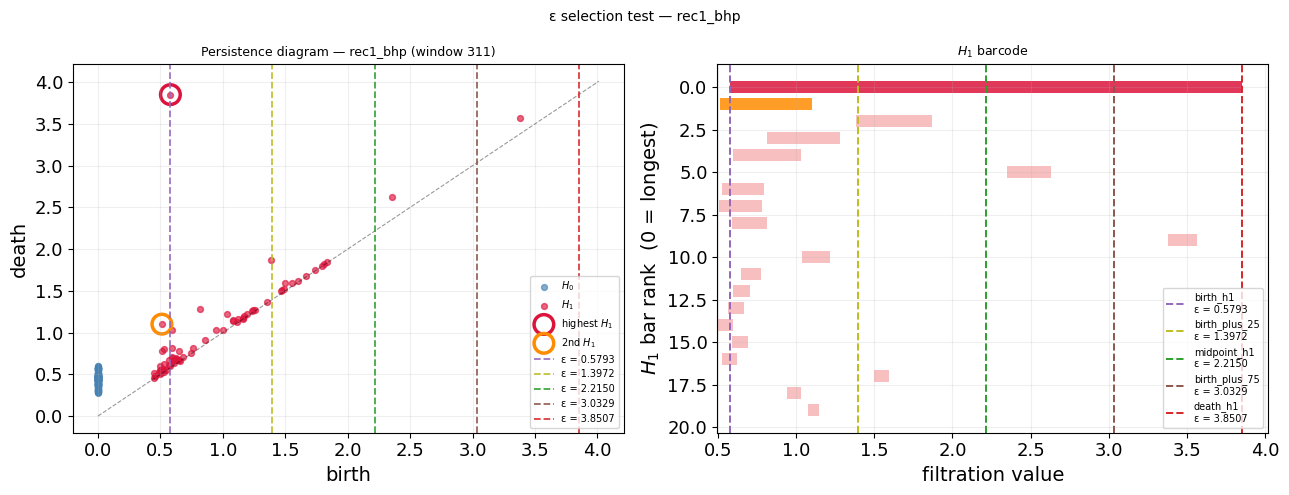

Loading cached sensitivity → nb02_sensitivity_rec1_bhp_w311.pkl
 step      strategy  epsilon  n_edges  n_triangles     eta_harm  eta_grad     eta_curl  beta1_hodge  spectral_gap
    1      birth_h1 0.579316      275           84 5.018950e-02  0.942592 6.846634e-32            8      4.477166
    2 birth_plus_25 1.397165     1174         3206 1.888858e-01  0.811114 1.072737e-31            3      1.415964
    3   midpoint_h1 2.215014     2572        16030 2.359243e-01  0.764076 6.171558e-32            1      1.459605
    4 birth_plus_75 3.032863     4190        44126 3.309815e-01  0.617365 5.165347e-02            1      1.552668
    5      death_h1 3.850712     6432       105034 1.200997e-14  0.257092 7.429077e-01            0     78.576537


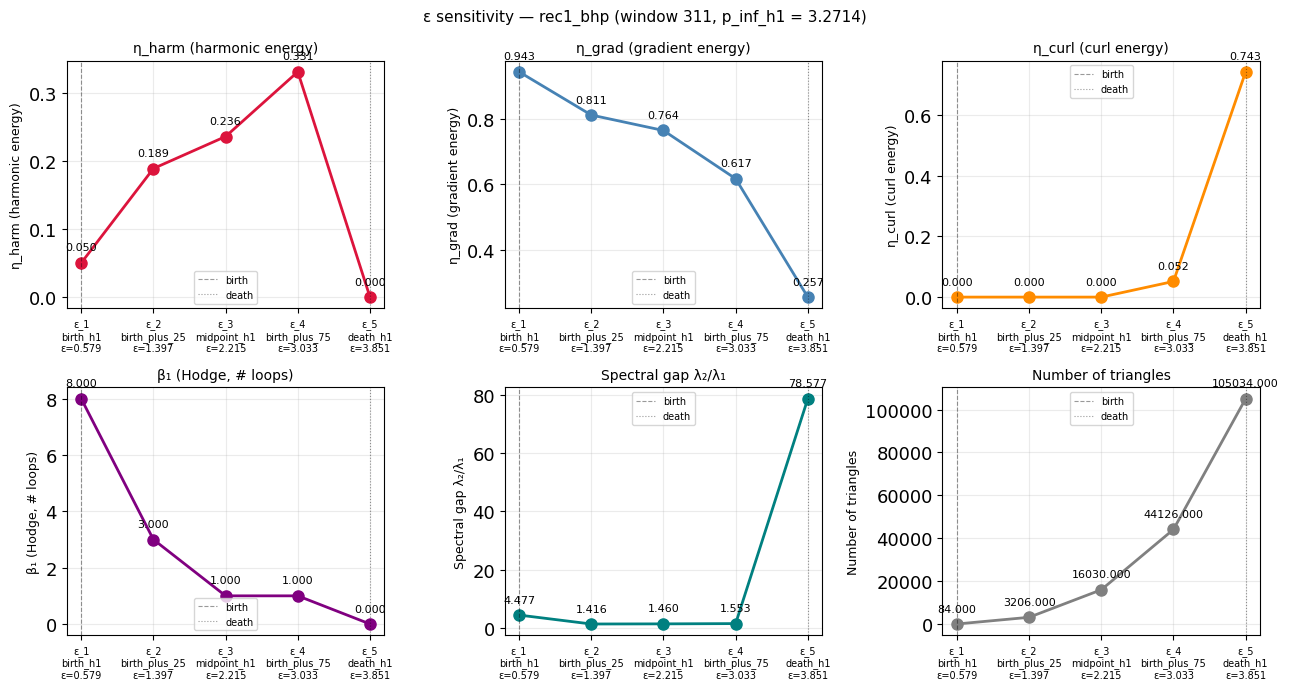

In [68]:
sens_rec1_bhp = epsilon_sensitivity(p1_bhp, m1_bhp, 'rec1_bhp')

══ [rec1_flp]  window 309   p_inf_h1 = 0.2671 ══


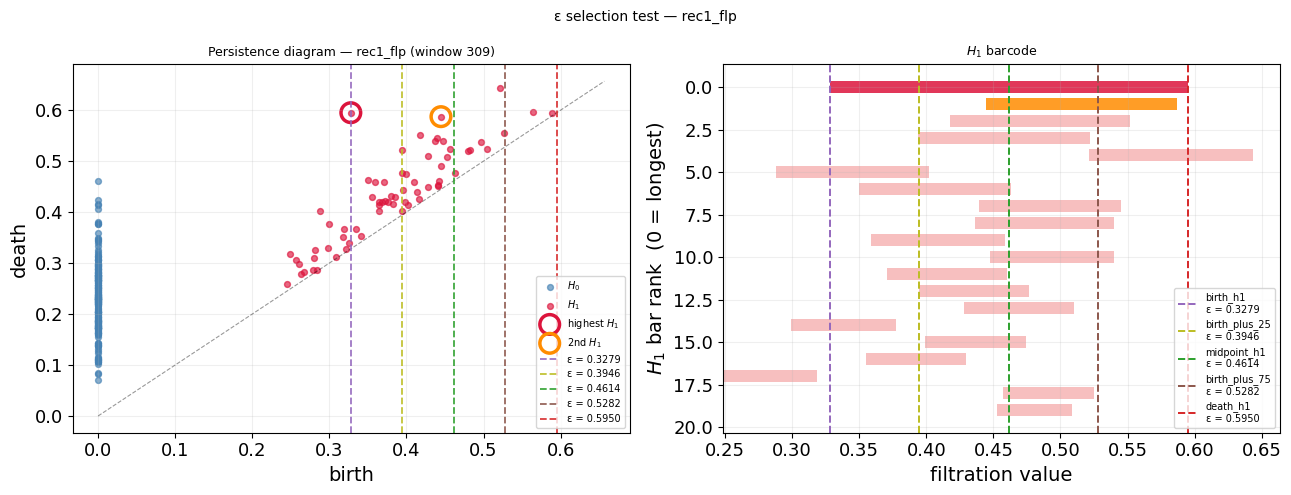

Loading cached sensitivity → nb02_sensitivity_rec1_flp_w309.pkl
 step      strategy  epsilon  n_edges  n_triangles  eta_harm  eta_grad  eta_curl  beta1_hodge  spectral_gap
    1      birth_h1 0.327856      372          290  0.033075  0.549204  0.417643            7      1.097067
    2 birth_plus_25 0.394641      629         1019  0.015665  0.383855  0.600038           10      0.000000
    3   midpoint_h1 0.461427     1068         3034  0.011030  0.226768  0.762202           10      0.000000
    4 birth_plus_75 0.528213     1677         8102  0.002321  0.133067  0.864612           10      0.000000
    5      death_h1 0.594998     2466        18379  0.000806  0.084128  0.915066            5      1.195388


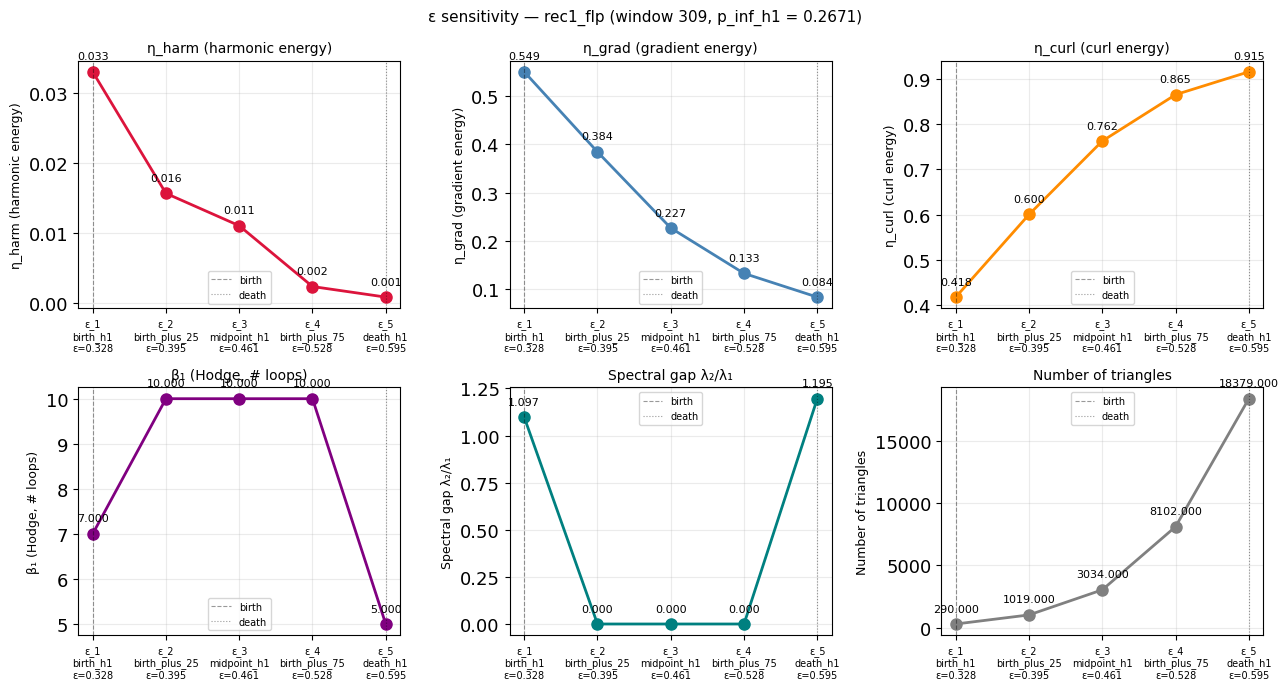

In [69]:
sens_rec1_flp = epsilon_sensitivity(p1_flp, m1_flp, 'rec1_flp')

══ [rec2_bhp]  window 450   p_inf_h1 = 5.4754 ══


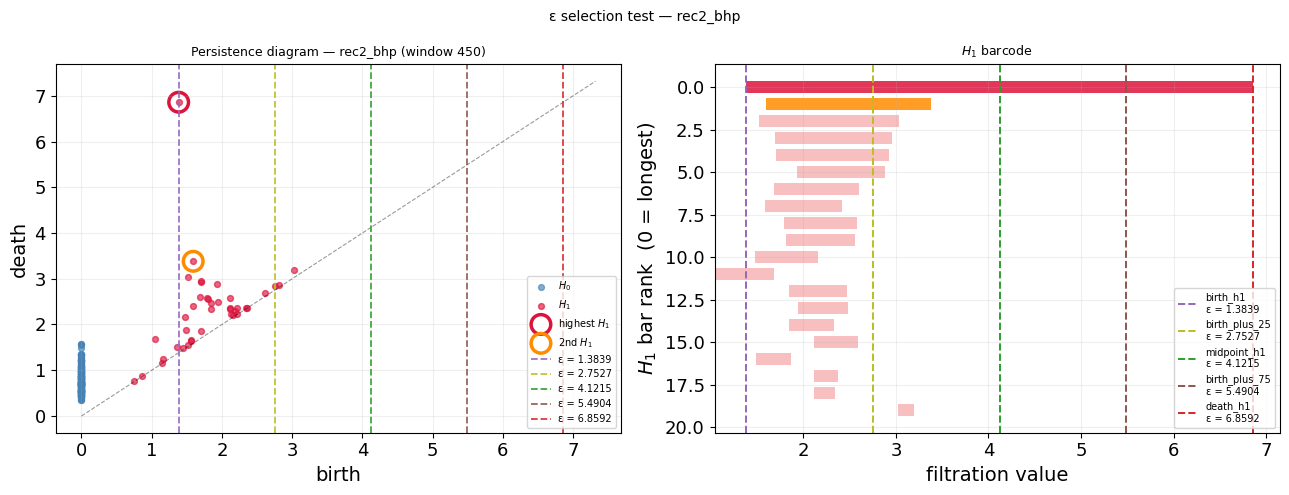

Loading cached sensitivity → nb02_sensitivity_rec2_bhp_w450.pkl
 step      strategy  epsilon  n_edges  n_triangles  eta_harm  eta_grad     eta_curl  beta1_hodge  spectral_gap
    1      birth_h1 1.383859      339          229  0.147350  0.847695 3.041892e-31            2     10.214553
    2 birth_plus_25 2.752701     1542         5481  0.710580  0.289420 2.746721e-31            7      1.183642
    3   midpoint_h1 4.121543     3683        34251  0.831821  0.168179 1.927878e-31            1      2.120940
    4 birth_plus_75 5.490385     5693        83275  0.884961  0.115039 1.232835e-31            1      1.597975
    5      death_h1 6.859227     7772       156203  0.919818  0.080182 8.299842e-32            1      1.029750


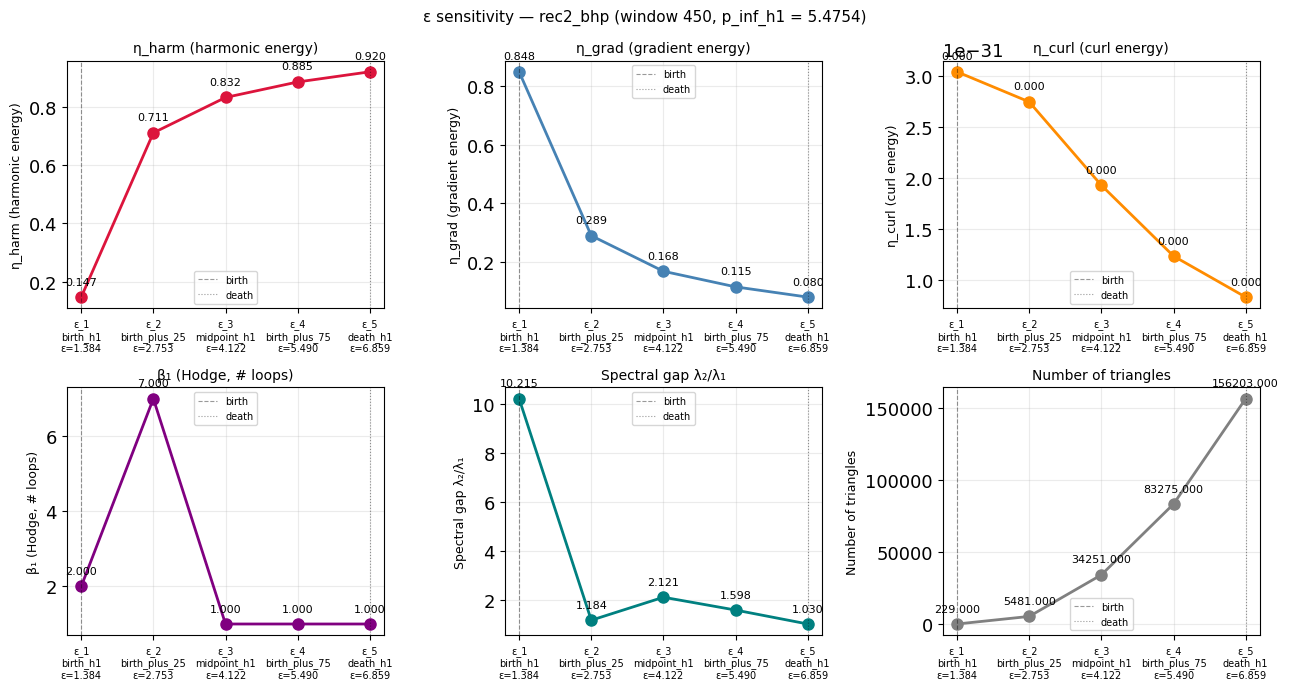

In [70]:
sens_rec2_bhp = epsilon_sensitivity(p2_bhp, m2_bhp, 'rec2_bhp')

══ [rec2_flp]  window 531   p_inf_h1 = 0.6766 ══


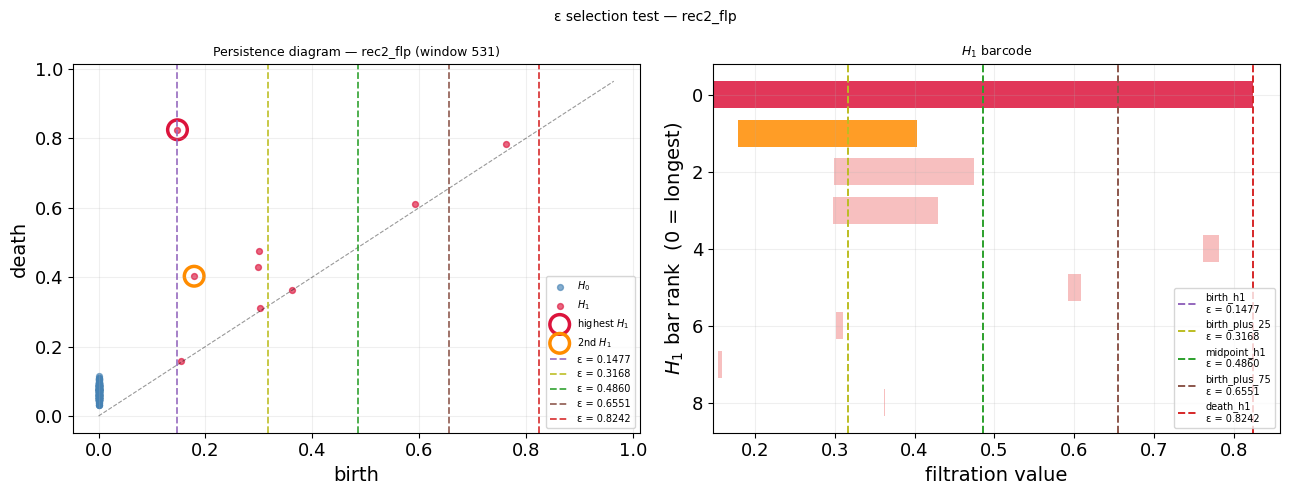

Loading cached sensitivity → nb02_sensitivity_rec2_flp_w531.pkl
 step      strategy  epsilon  n_edges  n_triangles     eta_harm  eta_grad     eta_curl  beta1_hodge  spectral_gap
    1      birth_h1  0.14769      349          201 3.524027e-01  0.622938 5.710616e-31            1      3.221319
    2 birth_plus_25  0.31683     1188         3490 3.952193e-01  0.604781 3.933751e-31            5      1.406270
    3   midpoint_h1  0.48597     2825        21072 4.364638e-01  0.563536 2.192532e-31            1      1.805790
    4 birth_plus_75  0.65511     5105        69338 5.043188e-01  0.495681 1.255177e-31            1      2.173487
    5      death_h1  0.82425     8087       171024 3.735533e-14  0.300598 6.994025e-01            0    427.315545


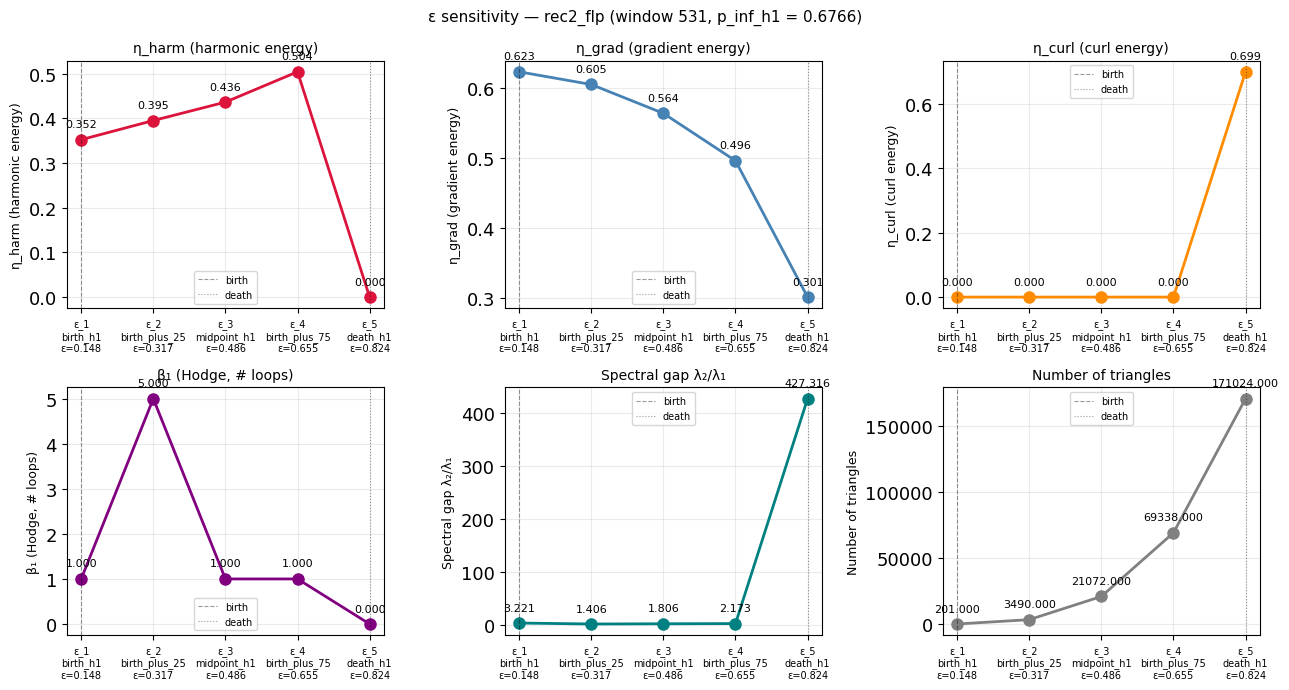

In [71]:
sens_rec2_flp = epsilon_sensitivity(p2_flp, m2_flp, 'rec2_flp')

### 5b″. Manual ε selection

After inspecting the four sensitivity reports above, set the chosen ε per
dataset here. Phase 2 reads `MANUAL_EPS` directly — a `None` entry falls
back to the legacy per-window auto-selection
(`epsilon_from_diagram(strategy='second_persistent_half')`).

> ⚠️ The cached Phase-2 Hodge results (`../data/nb02_hodge_<tag>.pkl`)
> were computed with the previous ε strategy. **Delete the relevant
> cache files before re-running §5c** if you change `MANUAL_EPS`.

In [72]:
# Fill these in after looking at the four sensitivity plots above.
# Leave a value as None to fall back to the auto per-window strategy.
MANUAL_EPS = { 
    'rec1_bhp': 0.308205,   
    'rec1_flp': 0.245331,
    'rec2_bhp': 5.490385,
    'rec2_flp': 0.65511,
}
for tag, eps in MANUAL_EPS.items():
    print(f"  {tag:10s}  ε = {eps}")

  rec1_bhp    ε = 0.308205
  rec1_flp    ε = 0.245331
  rec2_bhp    ε = 5.490385
  rec2_flp    ε = 0.65511


### 5c. Phase 2 — Hodge decomposition on selected windows

For windows above the threshold, build the Vietoris–Rips complex, run Hodge decomposition,
and compute the L₁ spectrum.  Unselected windows are filled with `NaN` so that the result
DataFrames have the same length as the persistence output (convenient for plotting).

In [73]:
_HODGE_EMPTY = dict(
    eta_harm=np.nan, eta_grad=np.nan, eta_curl=np.nan,
    harm_curl_ratio=np.nan, beta1_hodge=np.nan,
    lambda1=np.nan, spectral_gap=np.nan,
)

def run_hodge_selected(payload, mask, cache_tag, eps_fixed=None):
    """Run Hodge one window at a time; checkpoint after every window.

    If `eps_fixed` is given, that ε is used for every window. Otherwise
    each window picks its own ε via
    ``epsilon_from_diagram(strategy='second_persistent_half')``.

    After each window the result is appended to a checkpoint dict and
    flushed to disk, so a crash loses at most the current window.
    On restart, already-computed windows are skipped automatically.

    Old per-batch checkpoints (from the previous parallel implementation)
    are migrated into the new format on first run so no work is repeated.
    """
    cache      = CACHE_DIR / f"nb02_hodge_{cache_tag}.pkl"
    checkpoint = CACHE_DIR / f"nb02_hodge_{cache_tag}_ckpt.pkl"
    pers_df    = payload['pers']
    embeddings = payload['embeddings']
    diagrams   = payload['diagrams']

    if cache.exists():
        print(f"  Loading Hodge {cache_tag} …")
        with open(cache, "rb") as fh:
            hodge_df = pickle.load(fh)
    else:
        indices = np.where(mask)[0]
        n_sel   = len(indices)

        # ── Load or initialise per-window checkpoint ───────────────────────
        if checkpoint.exists():
            with open(checkpoint, "rb") as fh:
                computed = pickle.load(fh)
            print(f"  Resuming Hodge {cache_tag}: "
                  f"{len(computed)}/{n_sel} windows already done")
        else:
            # Migrate old per-batch checkpoints if present
            computed = {}
            for b in range(10_000):
                bc = CACHE_DIR / f"nb02_hodge_{cache_tag}_b{b:03d}.pkl"
                if not bc.exists():
                    break
                with open(bc, "rb") as fh:
                    batch_res = pickle.load(fh)
                for k, res in enumerate(batch_res):
                    win_idx = b * HODGE_BATCH + k
                    if win_idx < n_sel:
                        computed[int(indices[win_idx])] = res
            if computed:
                print(f"  Migrated {len(computed)} windows from old batch checkpoints")

        # ── Pre-fill results array ─────────────────────────────────────────
        all_rows = [dict(_HODGE_EMPTY) for _ in range(len(pers_df))]
        for idx, res in computed.items():
            all_rows[idx] = res

        remaining = [i for i in indices if int(i) not in computed]
        n_done    = len(computed)
        print(f"  Computing Hodge: {len(remaining)} remaining / {n_sel} total  ({cache_tag})")

        # ── One window at a time ───────────────────────────────────────────
        for k, i in enumerate(remaining):
            if eps_fixed is not None:
                eps     = float(eps_fixed)
                eps_str = f"{eps:.4f}  (manual)"
            else:
                eps     = epsilon_from_diagram(diagrams[i], strategy='second_persistent_half')
                eps_str = f"{eps:.4f}  (auto)" if eps is not None else "None"
            print(f"  [{cache_tag}]  window {n_done + k + 1}/{n_sel}  "
                  f"(global idx {i})  ε = {eps_str}")

            res          = hodge_features_one(embeddings[i], diagrams[i], eps=eps)
            all_rows[i]  = res
            computed[int(i)] = res

            with open(checkpoint, "wb") as fh:
                pickle.dump(computed, fh)

        # ── Finalise: write full cache, remove checkpoint & old batches ────
        hodge_df = pd.DataFrame(all_rows)
        with open(cache, "wb") as fh:
            pickle.dump(hodge_df, fh)
        checkpoint.unlink(missing_ok=True)
        for b in range(10_000):
            bc = CACHE_DIR / f"nb02_hodge_{cache_tag}_b{b:03d}.pkl"
            if not bc.exists():
                break
            bc.unlink()
        print(f"    → saved {cache.name}")

    return pd.concat([pers_df.reset_index(drop=True),
                      hodge_df.reset_index(drop=True)], axis=1)


print("Recording 1 — Hodge (selected windows only):")
r1_bhp = run_hodge_selected(p1_bhp, m1_bhp, 'rec1_bhp', MANUAL_EPS['rec1_bhp'])
r1_flp = run_hodge_selected(p1_flp, m1_flp, 'rec1_flp', MANUAL_EPS['rec1_flp'])

print("\nRecording 2 — Hodge (selected windows only):")
r2_bhp = run_hodge_selected(p2_bhp, m2_bhp, 'rec2_bhp', MANUAL_EPS['rec2_bhp'])
r2_flp = run_hodge_selected(p2_flp, m2_flp, 'rec2_flp', MANUAL_EPS['rec2_flp'])

# ── Export Hodge results (expensive!) to ../outputs/ ──────────────────────
_HODGE_COLS = ['eta_harm', 'eta_grad', 'eta_curl', 'harm_curl_ratio',
               'beta1_hodge', 'lambda1', 'spectral_gap']

for _tag, _res, _mask in [
    ('rec1_bhp', r1_bhp, m1_bhp),
    ('rec1_flp', r1_flp, m1_flp),
    ('rec2_bhp', r2_bhp, m2_bhp),
    ('rec2_flp', r2_flp, m2_flp),
]:
    _idx_sel = np.where(_mask)[0]
    _sub     = _res.iloc[_idx_sel].reset_index(drop=True)

    # full per-selected-window CSV (persistence + Hodge columns side-by-side)
    _csv_path = OUT_DIR / f"nb02_hodge_{_tag}.csv"
    _sub.insert(0, 'window_index', _idx_sel)
    _sub.to_csv(_csv_path, index=False)

    # compact NPZ with just the Hodge arrays
    _npz_path = OUT_DIR / f"nb02_hodge_{_tag}.npz"
    np.savez_compressed(
        _npz_path,
        window_index = _idx_sel.astype(np.int64),
        time         = _sub['time'].values,
        **{c: _sub[c].values for c in _HODGE_COLS if c in _sub.columns},
    )
    print(f"  [{_tag}]  saved {_csv_path.name}, {_npz_path.name}  "
          f"({len(_sub)} windows)")

Recording 1 — Hodge (selected windows only):
  Computing Hodge: 120 remaining / 120 total  (rec1_bhp)
  [rec1_bhp]  window 1/120  (global idx 238)  ε = 0.3082  (manual)
  [rec1_bhp]  window 2/120  (global idx 239)  ε = 0.3082  (manual)
  [rec1_bhp]  window 3/120  (global idx 240)  ε = 0.3082  (manual)
  [rec1_bhp]  window 4/120  (global idx 241)  ε = 0.3082  (manual)
  [rec1_bhp]  window 5/120  (global idx 242)  ε = 0.3082  (manual)
  [rec1_bhp]  window 6/120  (global idx 243)  ε = 0.3082  (manual)
  [rec1_bhp]  window 7/120  (global idx 244)  ε = 0.3082  (manual)
  [rec1_bhp]  window 8/120  (global idx 245)  ε = 0.3082  (manual)
  [rec1_bhp]  window 9/120  (global idx 246)  ε = 0.3082  (manual)
  [rec1_bhp]  window 10/120  (global idx 247)  ε = 0.3082  (manual)
  [rec1_bhp]  window 11/120  (global idx 248)  ε = 0.3082  (manual)
  [rec1_bhp]  window 12/120  (global idx 249)  ε = 0.3082  (manual)
  [rec1_bhp]  window 13/120  (global idx 250)  ε = 0.3082  (manual)
  [rec1_bhp]  window 14

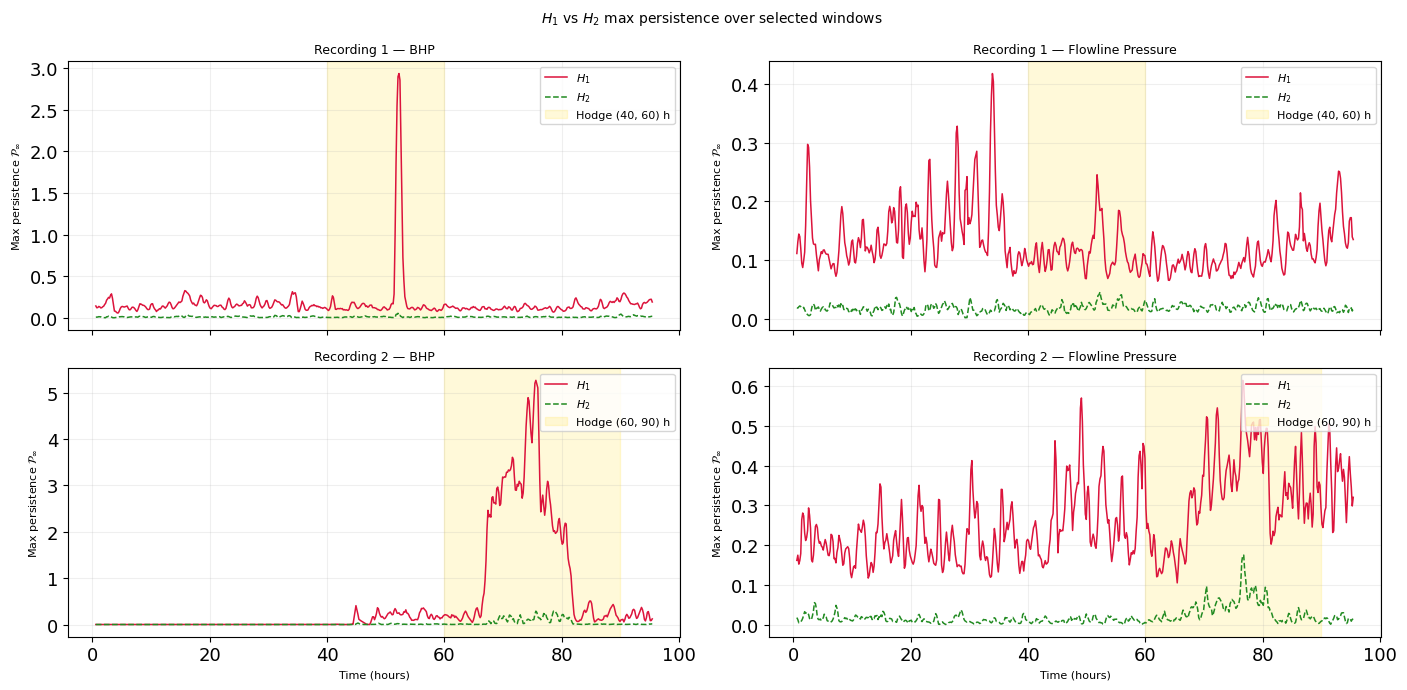

In [74]:
# H1 and H2 max persistence over the selected time windows
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex='col')

_panels = [
    (r1_bhp, r1_flp, 'Recording 1', REC1_HODGE_RANGE, 0),
    (r2_bhp, r2_flp, 'Recording 2', REC2_HODGE_RANGE, 1),
]
for bhp, flp, rec_title, hodge_range, row in _panels:
    for col, (res, ch, color) in enumerate([
        (bhp, 'BHP',              'steelblue'),
        (flp, 'Flowline Pressure','darkorange'),
    ]):
        ax  = axes[row, col]
        t_h = res['time'].values / 3600

        if 'p_inf_h1' in res.columns:
            ax.plot(t_h, res['p_inf_h1'].rolling(3, center=True).mean(),
                    lw=1.1, color='crimson',     label='$H_1$')
        if 'p_inf_h2' in res.columns:
            ax.plot(t_h, res['p_inf_h2'].rolling(3, center=True).mean(),
                    lw=1.1, color='forestgreen', label='$H_2$', ls='--')

        ax.axvspan(*hodge_range, color='gold', alpha=0.15,
                   label=f'Hodge {hodge_range} h')
        ax.set_title(f'{rec_title} — {ch}', fontsize=9)
        ax.set_ylabel(r'Max persistence $\mathcal{P}_\infty$', fontsize=8)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.2)

for ax in axes[-1]:
    ax.set_xlabel('Time (hours)', fontsize=8)

plt.suptitle('$H_1$ vs $H_2$ max persistence over selected windows', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Monitoring plots

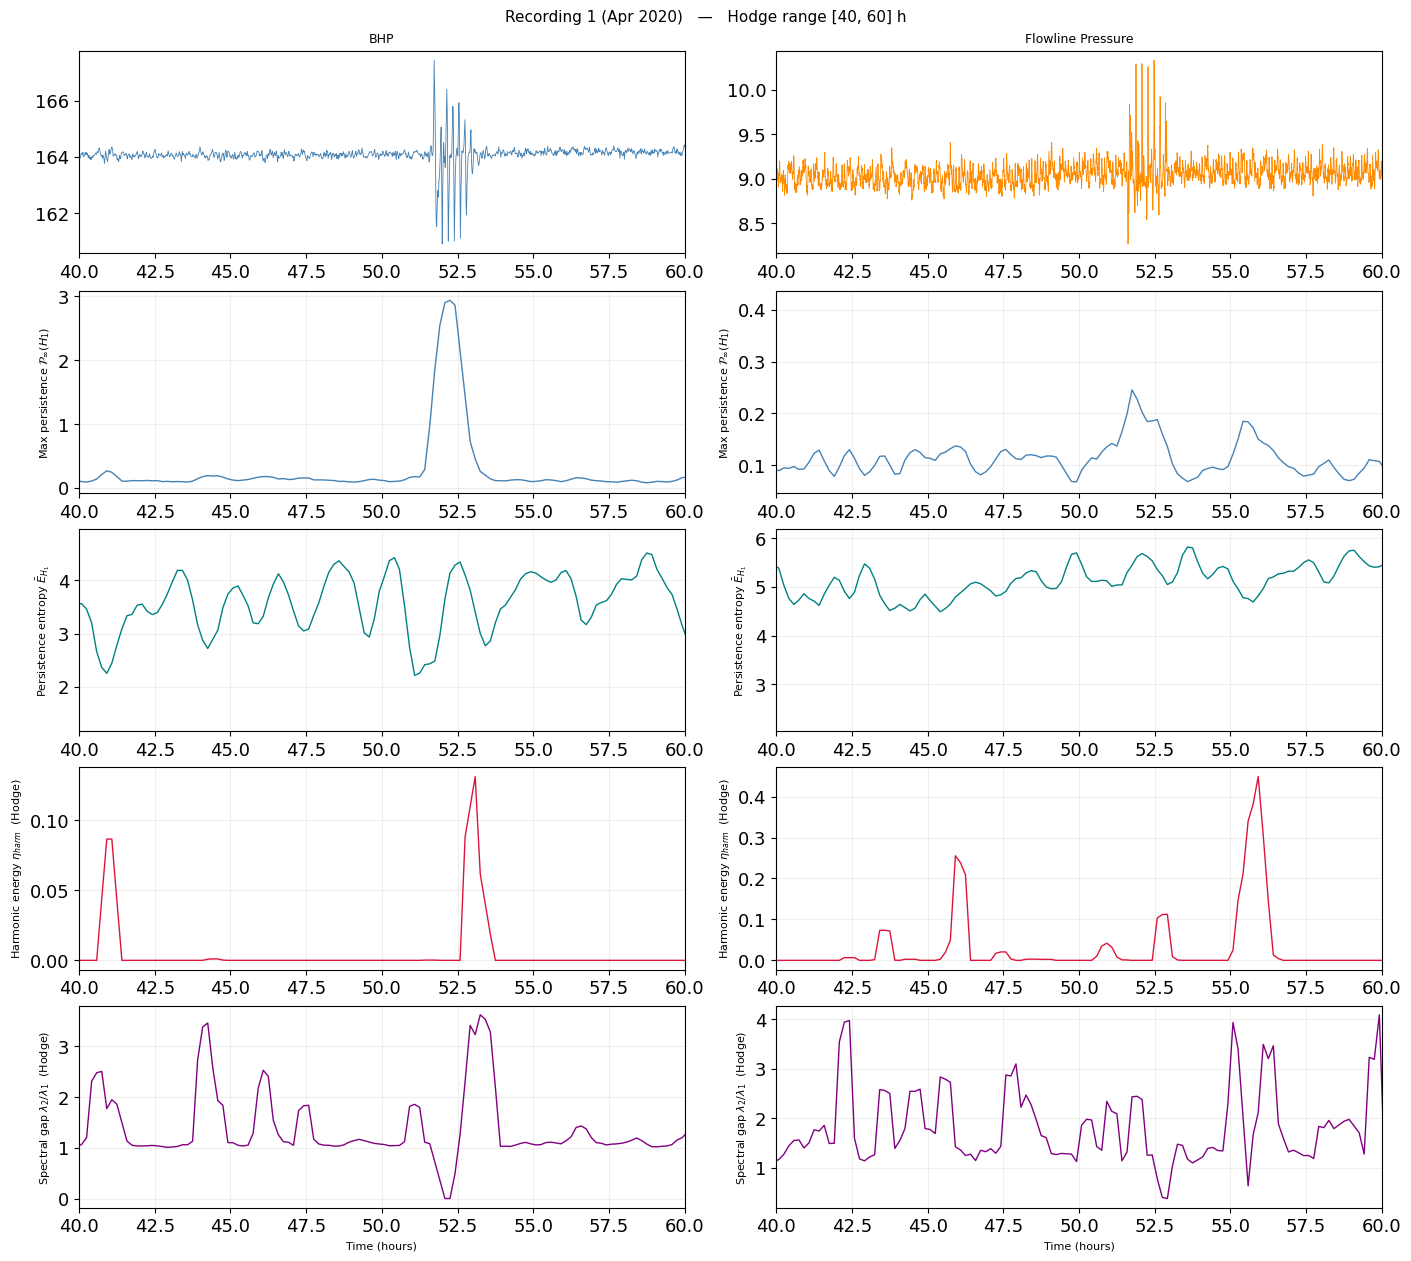

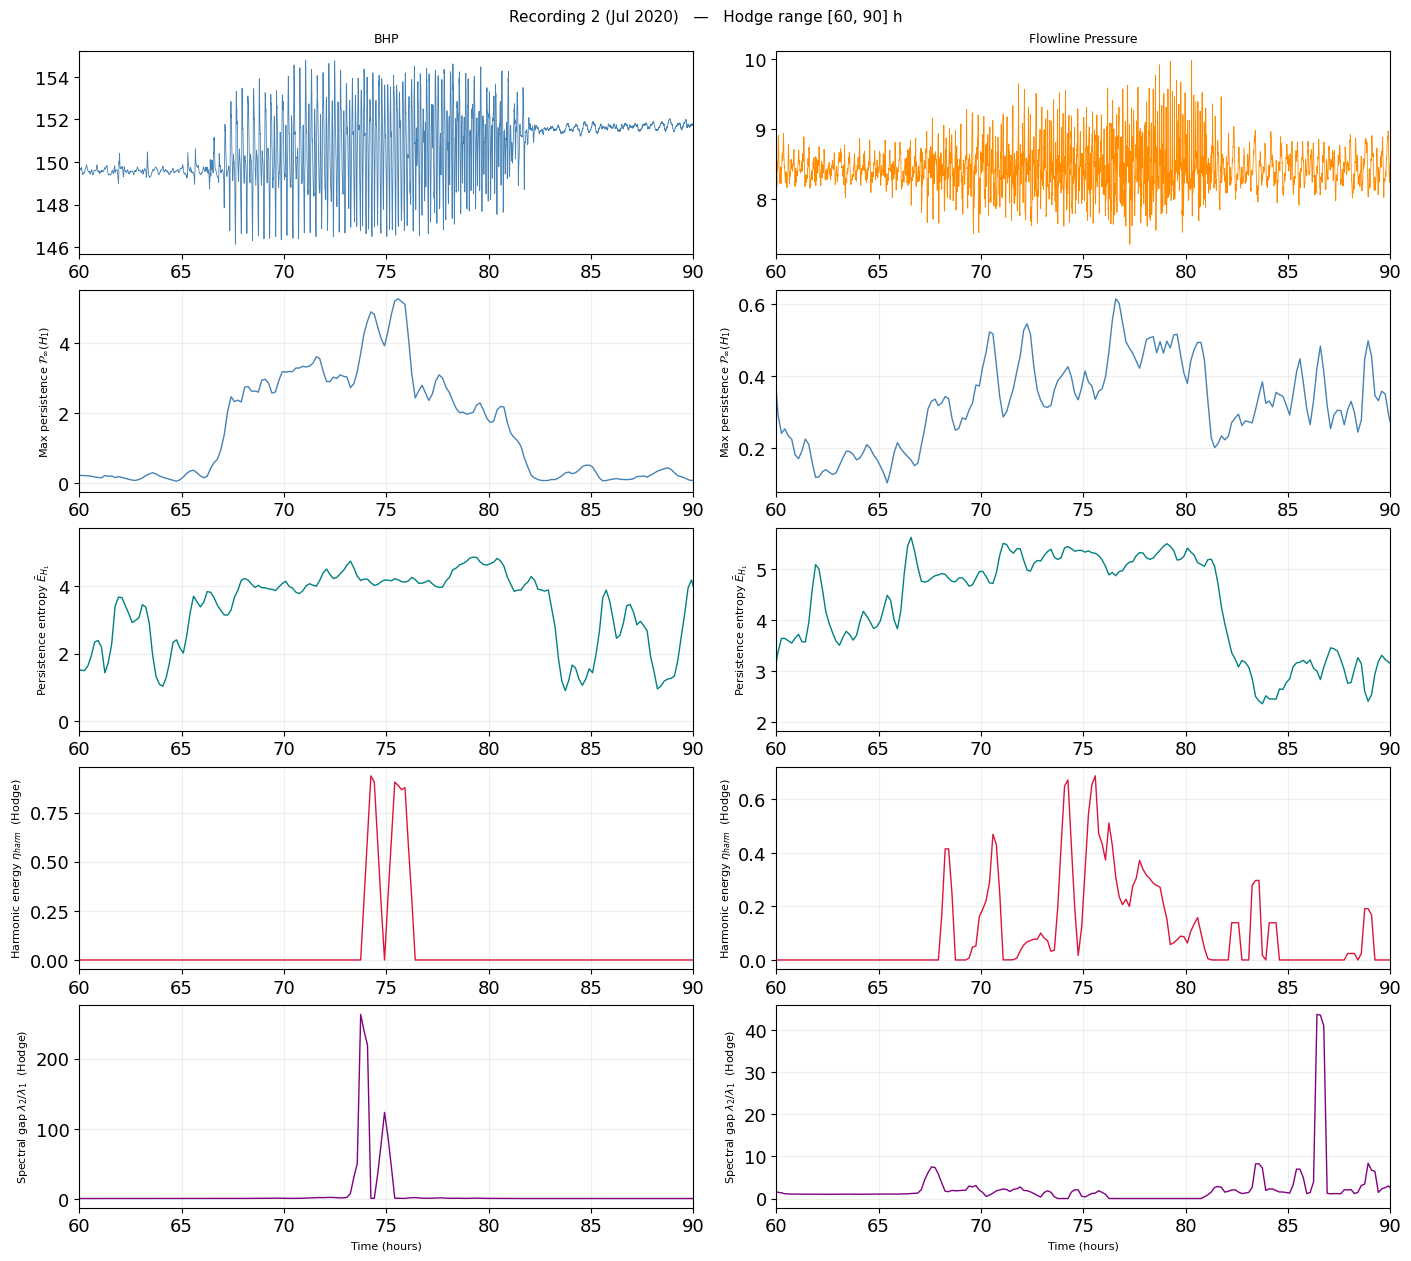

In [75]:
INDICATORS = [
    ('p_inf_h1',    r'Max persistence $\mathcal{P}_\infty(H_1)$', 'steelblue'),
    ('entropy_h1',  r'Persistence entropy $\bar{E}_{H_1}$',        'teal'),
    ('eta_harm',    r'Harmonic energy $\eta_{harm}$  (Hodge)',      'crimson'),
    ('spectral_gap',r'Spectral gap $\lambda_2/\lambda_1$  (Hodge)','purple'),
]

def plot_monitoring(res_bhp, res_flp, raw_df, title, xlim):
    """One figure per recording: raw signals + 4 indicators × 2 channels.

    xlim = (t0, t1) in hours: the time range used for Hodge decomposition.
    All panels (raw + indicators) are clipped to this range so the raw
    signal and the per-window features sit on the same x-axis.
    """
    n_rows = len(INDICATORS) + 1
    # sharex=False so the xlim we set per axis is authoritative for this figure
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 2.5 * n_rows), sharex=False)

    t0, t1 = float(xlim[0]), float(xlim[1])

    # ── Raw signals, clipped to the Hodge range ───────────────────────────
    t_raw = raw_df['time_s'].values / 3600
    raw_mask = (t_raw >= t0) & (t_raw <= t1)
    axes[0, 0].plot(t_raw[raw_mask], raw_df['BHP'].values[raw_mask],
                    lw=0.6, color='steelblue')
    axes[0, 1].plot(t_raw[raw_mask], raw_df['Flowline Pressure'].values[raw_mask],
                    lw=0.6, color='darkorange')
    axes[0, 0].set_title('BHP',              fontsize=9)
    axes[0, 1].set_title('Flowline Pressure', fontsize=9)

    # ── Per-window indicators ─────────────────────────────────────────────
    # min_periods=1 so the rolling mean is defined at the boundaries of the
    # Hodge mask; otherwise Hodge curves (NaN outside the mask) lose their
    # first/last masked window to NaN and appear shifted vs persistence.
    for row, (col, label, color) in enumerate(INDICATORS, start=1):
        for ch_i, res in enumerate([res_bhp, res_flp]):
            ax = axes[row, ch_i]
            if col in res.columns:
                t_h  = res['time'].values / 3600
                vals = res[col].rolling(3, center=True, min_periods=1).mean()
                ax.plot(t_h, vals, lw=1.0, color=color)
            ax.set_ylabel(label, fontsize=8)
            ax.grid(alpha=0.2)

    # ── Force the requested xlim on every panel (override any autoscale) ──
    for ax_row in axes:
        for ax in ax_row:
            ax.set_xlim(t0, t1)
            ax.autoscale(enable=False, axis='x')

    for ax in axes[-1]:
        ax.set_xlabel('Time (hours)', fontsize=8)
    fig.suptitle(f"{title}   —   Hodge range [{t0:g}, {t1:g}] h", fontsize=11)
    plt.show()


plot_monitoring(r1_bhp, r1_flp, df1, 'Recording 1 (Apr 2020)', REC1_HODGE_RANGE)
plot_monitoring(r2_bhp, r2_flp, df2, 'Recording 2 (Jul 2020)', REC2_HODGE_RANGE)


## 7. BHP vs Flowline Pressure: direct channel comparison

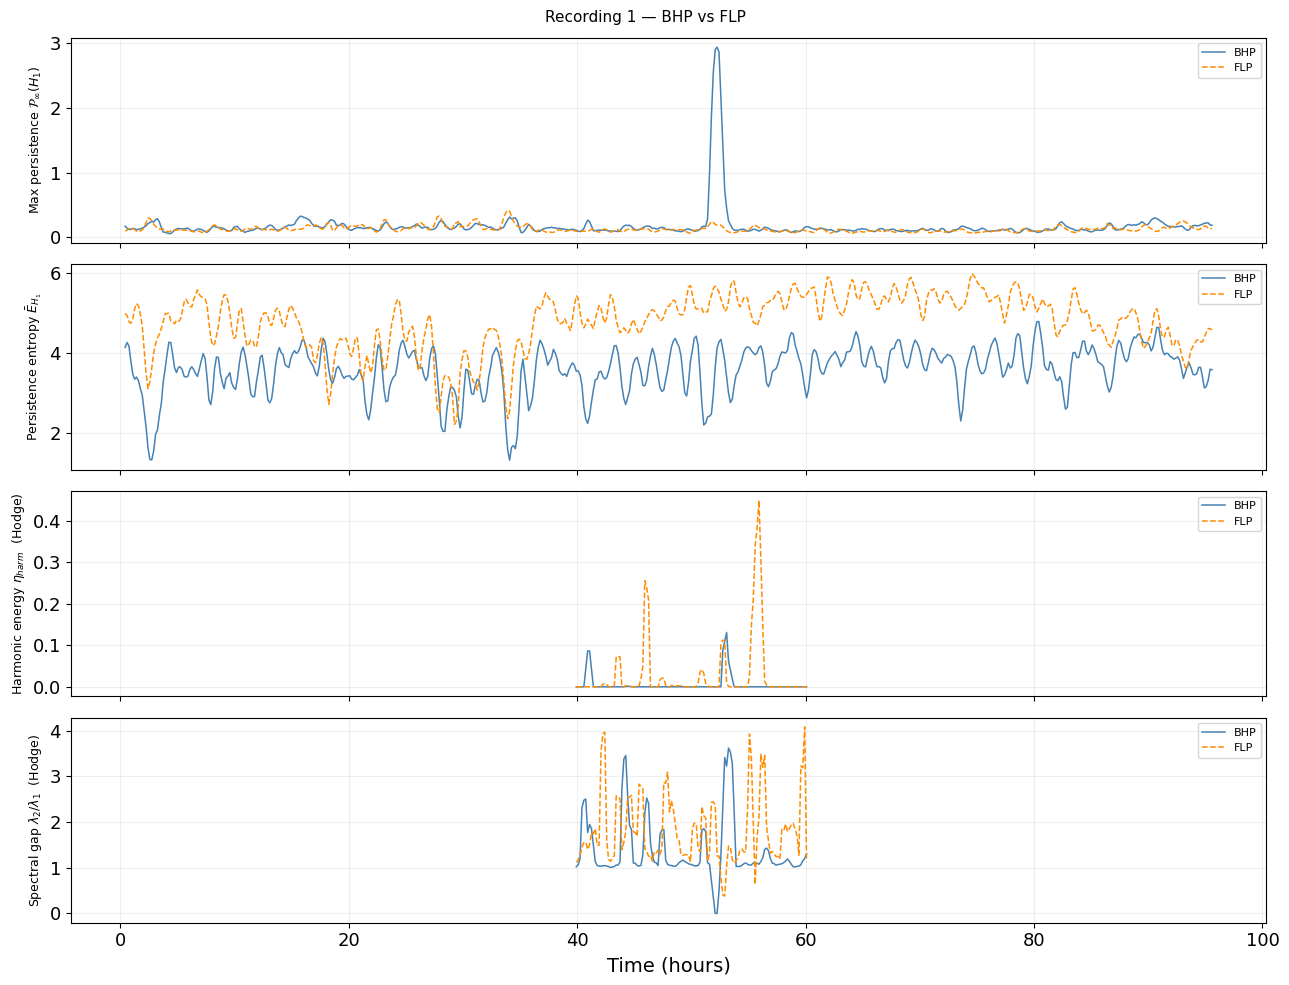

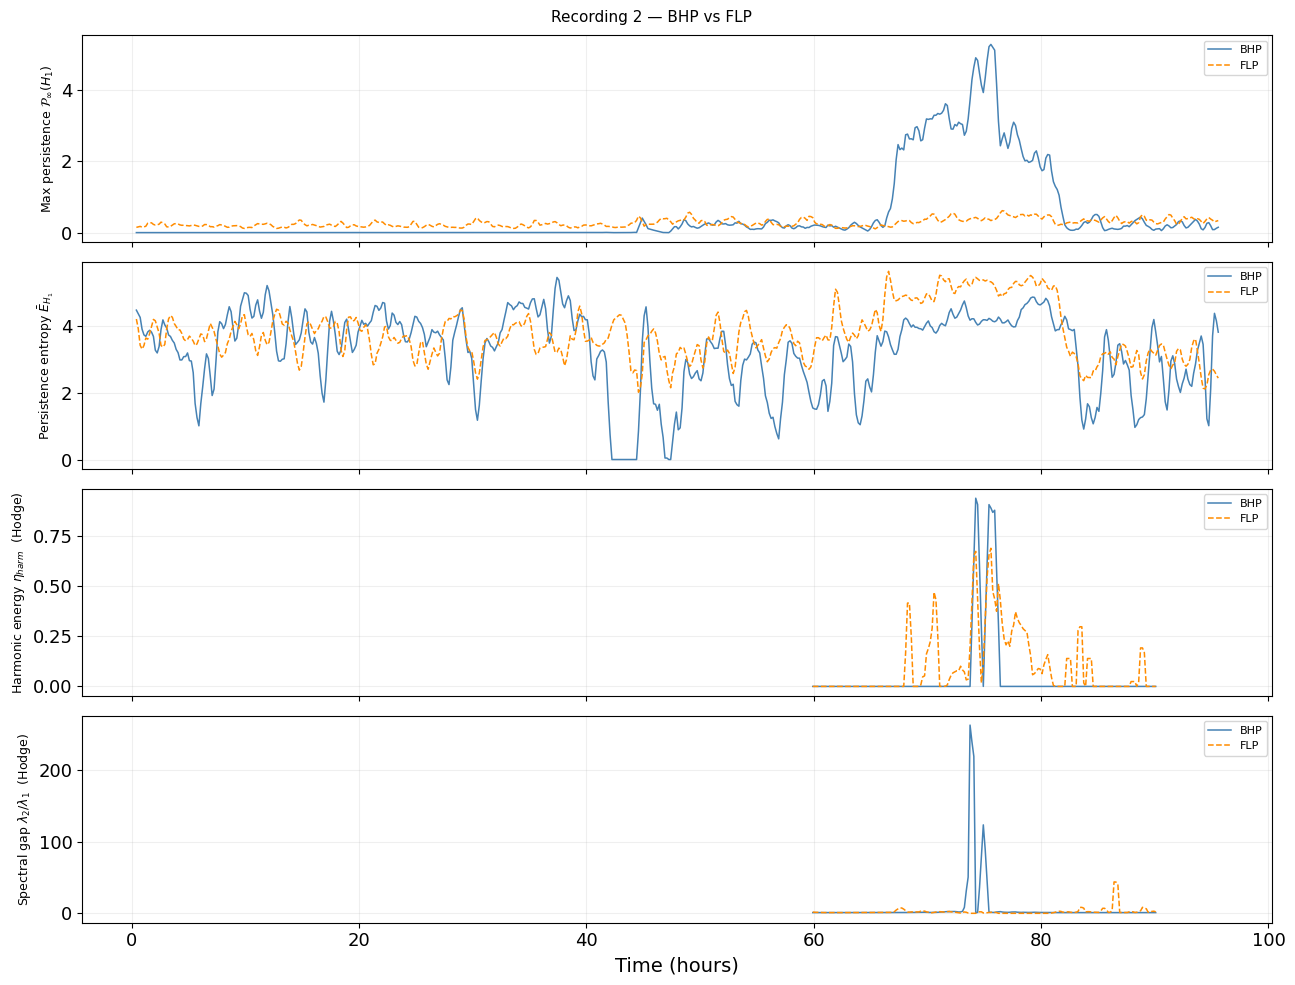

In [77]:
def compare_channels(res_bhp, res_flp, title):
    """Overlay BHP and FLP indicators on shared axes."""
    fig, axes = plt.subplots(len(INDICATORS), 1, figsize=(13, 10), sharex=True)
    for ax, (col, label, _) in zip(axes, INDICATORS):
        for res, ch, color, ls in [
            (res_bhp, 'BHP', 'steelblue',  '-'),
            (res_flp, 'FLP', 'darkorange', '--'),
        ]:
            if col in res.columns:
                t_h  = res['time'].values / 3600
                vals = res[col].rolling(3, center=True, min_periods=1).mean()
                ax.plot(t_h, vals, lw=1.1, color=color, ls=ls, label=ch)
        ax.set_ylabel(label, fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.2)
    axes[-1].set_xlabel('Time (hours)')
    fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

compare_channels(r1_bhp, r1_flp, 'Recording 1 — BHP vs FLP')
compare_channels(r2_bhp, r2_flp, 'Recording 2 — BHP vs FLP')
